In [9]:
import os, sys
import math
from copy import deepcopy
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

import torch as th
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
os.environ['DGLBACKEND'] = 'pytorch'
import dgl
from dgl.data import DGLDataset
from dgl.dataloading import GraphDataLoader
from torch.utils.data import Subset
from torch.utils.data.sampler import SubsetRandomSampler

import dgl.function as fn

/Users/nad/miniconda3/envs/dgl_env/lib/python3.12/site-packages/torchdata/datapipes/__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()
/Users/nad/miniconda3/envs/dgl_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
from scripts.n15_create_dgl_dataset import GraphsFromCSVDataset
import config

In [11]:
dataset = GraphsFromCSVDataset(
        nodes_csv="/Users/nad/mobiraph/data/n33_dotplots/params_20_16_plant_new/nodes.csv",
        edges_csv="/Users/nad/mobiraph/data/n33_dotplots/params_20_16_plant_new/edges.csv",
        metadata_json="/Users/nad/mobiraph/data/n26_sv_processed/hierarchy_sequences_sv_plants.json",
        hierarchy_root="Class I (Retrotransposons)",
        save_dir="/Users/nad/mobiraph/data/n33_dotplots/dgl_dataset_class1_plants_5emb",
        force_reload=False,
        verbose=True,
    )
len(dataset)

9061

In [29]:
import numpy as np
import torch

def dataset_stats(dataset):
    num_nodes = []
    num_edges = []
    degrees = []

    for g, _ in dataset:
        n = g.num_nodes()
        e = g.num_edges()

        num_nodes.append(n)
        num_edges.append(e)

        # степени вершин
        deg = g.in_degrees().numpy()  # или out_degrees()
        degrees.append(deg)

    degrees = np.concatenate(degrees)

    print("=== Graph stats ===")
    print(f"num graphs: {len(dataset)}")

    print("\n--- Nodes ---")
    print(f"min: {np.min(num_nodes)}")
    print(f"max: {np.max(num_nodes)}")
    print(f"mean: {np.mean(num_nodes):.2f}")

    print("\n--- Edges ---")
    print(f"min: {np.min(num_edges)}")
    print(f"max: {np.max(num_edges)}")
    print(f"mean: {np.mean(num_edges):.2f}")

    print("\n--- Degree ---")
    print(f"min: {degrees.min()}")
    print(f"max: {degrees.max()}")
    print(f"mean: {degrees.mean():.2f}")

dataset_stats(dataset)

=== Graph stats ===
num graphs: 9061

--- Nodes ---
min: 2
max: 19947
mean: 1669.80

--- Edges ---
min: 2
max: 869290
mean: 4188.05

--- Degree ---
min: 0
max: 926
mean: 2.51


In [5]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl

from torch.utils.data import DataLoader, Subset
from dgl.nn import GraphConv, AvgPooling, MaxPooling

# импорт твоего датасета
# from your_dataset_file import GraphsFromCSVDataset


# =========================
# 1. Фиксация seed
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# =========================
# 2. Collate для батчинга графов
# =========================
def collate_fn(samples):
    graphs, labels = zip(*samples)
    batched_graph = dgl.batch(graphs)
    labels = torch.tensor(labels, dtype=torch.long)
    return batched_graph, labels


# =========================
# 3. Модель GCN для graph classification
# =========================
class GCNGraphClassifier(nn.Module):
    def __init__(
        self,
        in_feats,
        hidden_feats,
        num_classes,
        dropout=0.2,
        use_max_pool=True,
    ):
        super().__init__()

        self.conv1 = GraphConv(in_feats, hidden_feats, allow_zero_in_degree=True)
        self.conv2 = GraphConv(hidden_feats, hidden_feats, allow_zero_in_degree=True)

        self.avg_pool = AvgPooling()
        self.max_pool = MaxPooling() if use_max_pool else None

        readout_dim = hidden_feats * 2 if use_max_pool else hidden_feats

        self.classifier = nn.Sequential(
            nn.Linear(readout_dim, hidden_feats),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_feats, num_classes),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, g):
        x = g.ndata["feat"].float()

        x = self.conv1(g, x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(g, x)
        x = F.relu(x)

        g.ndata["h"] = x

        h_avg = self.avg_pool(g, x)

        if self.max_pool is not None:
            h_max = self.max_pool(g, x)
            hg = torch.cat([h_avg, h_max], dim=1)
        else:
            hg = h_avg

        logits = self.classifier(hg)
        return logits


# =========================
# 4. Метрики
# =========================
@torch.no_grad()
def evaluate(model, dataloader, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    criterion = nn.CrossEntropyLoss()

    for bg, labels in dataloader:
        bg = bg.to(device)
        labels = labels.to(device)

        logits = model(bg)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    return avg_loss, acc


# =========================
# 5. Обучение
# =========================
def train_model(
    dataset,
    split_idx,
    hidden_feats=64,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=50,
    dropout=0.2,
    device=None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    train_dataset = Subset(dataset, split_idx["train"].tolist())
    val_dataset = Subset(dataset, split_idx["valid"].tolist())
    test_dataset = Subset(dataset, split_idx["test"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
    )

    # размер входных признаков
    sample_graph, _ = dataset[0]
    in_feats = sample_graph.ndata["feat"].shape[1]
    num_classes = len(dataset.label2id)

    model = GCNGraphClassifier(
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        num_classes=num_classes,
        dropout=dropout,
        use_max_pool=True,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for bg, labels in train_loader:
            bg = bg.to(device)
            labels = labels.to(device)

            logits = model(bg)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        val_loss, val_acc = evaluate(model, val_loader, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc = evaluate(model, test_loader, device)
    print(f"\nBest val_acc={best_val_acc:.4f}")
    print(f"Test loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return model



In [33]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl

from torch.utils.data import DataLoader, Subset
from dgl.nn import GATConv, AvgPooling, MaxPooling


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def collate_fn(samples):
    graphs, labels = zip(*samples)
    batched_graph = dgl.batch(graphs)
    labels = torch.tensor(labels, dtype=torch.long)
    return batched_graph, labels


class GATGraphClassifier(nn.Module):
    def __init__(
        self,
        in_feats,
        hidden_feats,
        num_classes,
        num_heads=4,
        dropout=0.2,
        use_max_pool=True,
    ):
        super().__init__()

        self.gat1 = GATConv(
            in_feats=in_feats,
            out_feats=hidden_feats,
            num_heads=num_heads,
            feat_drop=dropout,
            attn_drop=dropout,
            allow_zero_in_degree=True,
        )

        self.gat2 = GATConv(
            in_feats=hidden_feats,
            out_feats=hidden_feats,
            num_heads=num_heads,
            feat_drop=dropout,
            attn_drop=dropout,
            allow_zero_in_degree=True,
        )

        self.avg_pool = AvgPooling()
        self.max_pool = MaxPooling() if use_max_pool else None

        readout_dim = hidden_feats * 2 if use_max_pool else hidden_feats

        self.classifier = nn.Sequential(
            nn.Linear(readout_dim, hidden_feats),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_feats, num_classes),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, g):
        x = g.ndata["feat"].float()

        # [N, num_heads, hidden_feats]
        x = self.gat1(g, x)
        x = x.mean(dim=1)  # -> [N, hidden_feats]
        x = F.relu(x)
        x = self.dropout(x)

        # [N, num_heads, hidden_feats]
        x = self.gat2(g, x)
        x = x.mean(dim=1)  # -> [N, hidden_feats]
        x = F.relu(x)

        g.ndata["h"] = x

        h_avg = self.avg_pool(g, x)

        if self.max_pool is not None:
            h_max = self.max_pool(g, x)
            hg = torch.cat([h_avg, h_max], dim=1)
        else:
            hg = h_avg

        logits = self.classifier(hg)
        return logits


@torch.no_grad()
def evaluate(model, dataloader, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    criterion = nn.CrossEntropyLoss()

    for bg, labels in dataloader:
        bg = bg.to(device)
        labels = labels.to(device)

        logits = model(bg)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    return avg_loss, acc



def train_model(
    dataset,
    split_idx,
    hidden_feats=64,
    num_heads=4,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=50,
    dropout=0.2,
    device=None,
    use_max_pool=True,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    train_dataset = Subset(dataset, split_idx["train"].tolist())
    val_dataset = Subset(dataset, split_idx["valid"].tolist())
    test_dataset = Subset(dataset, split_idx["test"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
    )

    sample_graph, _ = dataset[0]
    in_feats = sample_graph.ndata["feat"].shape[1]
    num_classes = len(dataset.label2id)

    model = GATGraphClassifier(
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        num_classes=num_classes,
        num_heads=num_heads,
        dropout=dropout,
        use_max_pool=use_max_pool,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for bg, labels in train_loader:
            bg = bg.to(device)
            labels = labels.to(device)

            logits = model(bg)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        val_loss, val_acc = evaluate(model, val_loader, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc = evaluate(model, test_loader, device)
    print(f"\nBest val_acc={best_val_acc:.4f}")
    print(f"Test loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return model

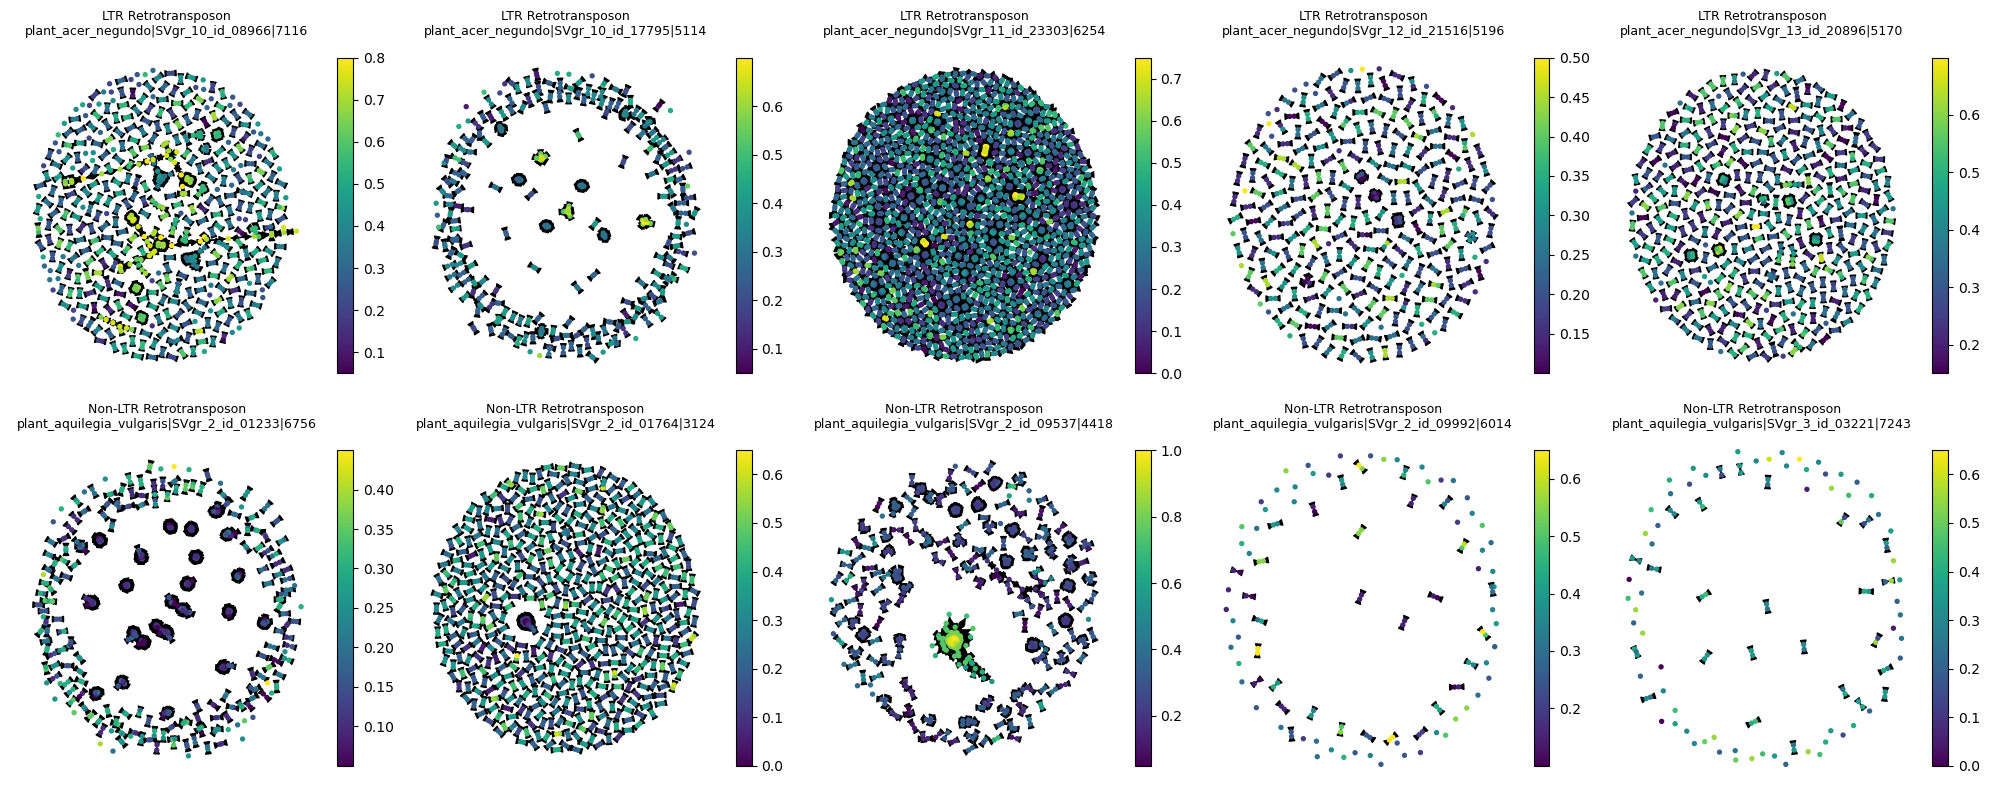

In [6]:
import dgl
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import numpy as np
from collections import defaultdict


def visualize_k_per_class(dataset, k=3, max_classes=None):
    class_graphs = defaultdict(list)

    for idx, (g, y) in enumerate(dataset):
        cls = int(y.item()) if hasattr(y, "item") else int(y)
        class_graphs[cls].append((idx, g))

    classes = sorted(class_graphs.keys())
    if max_classes is not None:
        classes = classes[:max_classes]

    selected = {c: class_graphs[c][:k] for c in classes if len(class_graphs[c]) > 0}
    classes = list(selected.keys())

    rows, cols = len(classes), k
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)

    for i, cls in enumerate(classes):
        for j in range(cols):
            ax = axes[i][j]

            if j >= len(selected[cls]):
                ax.axis("off")
                continue

            idx, g = selected[cls][j]
            nx_g = dgl.to_networkx(g)
            pos = nx.spring_layout(nx_g, seed=42)

            node_vals = g.ndata["feat"]
            node_vals = node_vals.detach().cpu().numpy() if hasattr(node_vals, "detach") else np.asarray(node_vals)
            node_vals = node_vals if node_vals.ndim == 1 else node_vals[:, 0]

            nx.draw(nx_g, pos, node_color=node_vals, cmap="viridis", node_size=8, ax=ax)

            sm = mpl.cm.ScalarMappable(
                cmap="viridis",
                norm=mpl.colors.Normalize(vmin=node_vals.min(), vmax=node_vals.max()),
            )
            sm.set_array([])
            fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)

            label = dataset.id2label[cls] if hasattr(dataset, "id2label") else str(cls)
            gid = dataset.graph_ids[idx] if hasattr(dataset, "graph_ids") else idx
            ax.set_title(f"{label}\n{gid}", fontsize=9)

    plt.tight_layout()
    plt.show()


visualize_k_per_class(dataset, k=5)

In [34]:
print("Число графов:", len(dataset))
print("Классы:", dataset.label2id)

split_idx = dataset.split_idx(
    train_ratio=0.9,
    val_ratio=0.05,
    test_ratio=0.05,
    seed=42,
    stratified=True,
)

model = train_model(
    dataset=dataset,
    split_idx=split_idx,
    hidden_feats=64,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=10,
    dropout=0.2,
    use_max_pool=False
)

KeyboardInterrupt: 

In [21]:
test_dataset = GraphsFromCSVDataset(
        nodes_csv="/Users/nad/mobiraph/data/n33_dotplots/params_20_16_insect/nodes.csv",
        edges_csv="/Users/nad/mobiraph/data/n33_dotplots/params_20_16_insect/edges.csv",
        metadata_json="/Users/nad/mobiraph/data/n26_sv_processed/hierarchy_sequences_sv_insects.json",
        hierarchy_root="",
        save_dir="/Users/nad/mobiraph/data/n33_dotplots/dgl_dataset_class1_insects",
        force_reload=True,
        verbose=True,
    )
len(test_dataset)

5723

In [22]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
)

In [30]:
dataset_stats(test_dataset)

=== Graph stats ===
num graphs: 5723

--- Nodes ---
min: 2
max: 16550
mean: 723.34

--- Edges ---
min: 2
max: 1394470
mean: 2970.15

--- Degree ---
min: 0
max: 629
mean: 4.11


In [23]:
@torch.no_grad()
def predict(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    for bg, labels in dataloader:
        bg = bg.to(device)

        logits = model(bg)
        preds = logits.argmax(dim=1).cpu()

        all_preds.append(preds)
        all_labels.append(labels)

    return torch.cat(all_preds), torch.cat(all_labels)

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"

preds, labels = predict(model, test_loader, device)

acc = (preds == labels).float().mean()
print("Test accuracy:", acc.item())

Test accuracy: 0.5608946084976196


In [31]:
torch.save(model.state_dict(), "/Users/nad/mobiraph/data/n33_dotplots/gat_model.pt")